In [1]:
import sys
import os

print("Python utilisé par Jupyter:")
print(sys.executable)
print("\nVersion:")
print(sys.version)

# Remonter jusqu'au répertoire ATOMOD
notebook_dir = os.getcwd()
atomod_dir = os.path.abspath(os.path.join(notebook_dir, '..', '..'))

print(f"Répertoire notebook: {notebook_dir}")
print(f"Répertoire ATOMOD: {atomod_dir}")

sys.path.insert(0, atomod_dir)

# Maintenant l'import fonctionne
import HBPy
print("✅ HBPy importé!")


import logging
# Configuration du logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)
from pathlib import Path

Python utilisé par Jupyter:
/home/bulou/src/essai/ATOMOD/venv/ATOMOD/bin/python3

Version:
3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
Répertoire notebook: /home/bulou/src/essai/ATOMOD/doc/tutorials
Répertoire ATOMOD: /home/bulou/src/essai/ATOMOD
✅ HBPy importé!


In [2]:
import HBPy
from HBPy.Molecule.Crystal import Crystal,Atom
from collections import defaultdict
import numpy
import matplotlib.pyplot as plt

/home/bulou/src/essai/ATOMOD/venv/ATOMOD/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [3]:
    status={
        'NP':True,
        'abtem':True,
        'feff':True,
        'atomic probability map':True,
        'optimization':False,
    }
    config={
        'run_dir':'run_dir',                          # répertoire de lancement
        'simul_dir':'simul',                          # répertoire de base de la simulation
        'train':{
            'TEM_img_dir'      : "train/TEM",        # répertoire de stockage des images TEM
            'EXAFS_dir'        : "train/EXAFS",      # répertoire de stockage des spectres EXAFS
            'prob_maps_img_dir': "train/prob_maps",  # répertoire de stockage des images TEM
            'nfo_dir'          : "train/nfo",        # répertoire des infos sur la gen. in silico
            'optimizer'        : "adam",
            'BATCH_SIZE'       :  4,
        },
        'NP':{
            'status':status['NP'],
            'seed':1,
            'structure':{
                'optimization':status['optimization'],
                'composition':['Pt','Co','Au','Pd','Rh'],
                'radius':4.0,
                'a':3.92,
            },
            'nvaccum':2.0,
        },
        'mace':{
            'model_path':'HBPy/Molecule/mace/20231203mace128L1_epoch199model'
        },
        'abtem':{
            'status':status['abtem'],
            'dx':0.04,
            'dy':0.04,
            'dz':4.08/2,
            'energy':300e3,
            'focal spread':40,
            'semiangle cutoff':20,
            'defocus':200,
            'cell scale':1.1
        },
        'atomic presence probability map':{
            'status':status['atomic probability map'],
            'ninter':{ # nombre d'intervalles entre deux positions atomiques
                'x':20,
                'y':20,
                'z':2
            },
            'sigma': .6  # en Å, largeur de la gaussienne ~ rayon atomique ou un peu moins
        },
        'image':{
            'xmin':0.0,
            'xmax':0.0,
            'ymin':0.0,
            'ymax':0.0,
            'H':128,
            'W':128,
            },
        'exafs':{
            'N_POINTS_EXAFS': 200,   # Nombre de points par spectre
        },
        'feff':{
            'status':status['feff'],
            'parameters':{
                'TITLE':'FEFF INPUT FILE',
                'DEBYE_TEMP': 190.0,
                'SCF_RADIUS': 5.0,
                'RPATH': 5.0,     # typique 2.2xdistance plus proches voisins. changer pour étudier la cvg des spectres
                'EXAFS' : 20.0,   # xkmax - default 20 ang.^-1
                'EDGE': {'Co':'K','Ni':'K','Ru':'K','Rh':'K','Pd':'K','Ir':'L3','Pt':'L3','Au':'L3'},
                'RMAX':8.0,
                'feff_dir':  '/home/bulou/ownCloud/Notebooks/M2P2_HEA/Home/Modelisation/ATOMOD/JFEFF/feff90/unix/',
                'input_save_dir':'./',
                'filename':'feff.inp',
                'list_pgm':['rdinp','atomic','dmdw','pot',
                            'opconsat', 
                            'screen',
                            'xsph',
                            'fms',
                            'mkgtr',
                            'path', 
                            'genfmt',
                            'ff2x',
                            'sfconv',
                            'compton',
                            'eels',
                            'ldos'
                            ]
            }
        }
    }
    

    config['run_dir']=Path.cwd()
    config['mace']['model_path']=str(Path("../../") / config['mace']['model_path'])


_______________________________________
# Etape 1 : construire la nanoparticules
 _______________________________________
#   Etape 1.1 : la structure

In [4]:
NP=Crystal()
NP.build(a=config['NP']['structure']['a'],
    radius=config['NP']['structure']['radius'],
    materials='NP')
NP.origin_at_mass_center()
logger.info(f"min={NP.qmin} max={NP.qmax}")
logger.info(f"Mass center={NP.MC}")
logger.info(f"Number of atoms={len(NP.atoms)}")

2026-07-05 07:23:52,746 [INFO] - <module>() - min=[-2.94 -2.94 -2.94] max=[2.94 2.94 2.94]
2026-07-05 07:23:52,747 [INFO] - <module>() - Mass center=[-4.44089210e-16 -1.33226763e-15 -1.33226763e-15]
2026-07-05 07:23:52,748 [INFO] - <module>() - Number of atoms=16


 #   Etape 1.2 : la distribution chimique   

In [5]:
NP.set_composition(config['NP']['structure']['composition'])
directory=config['run_dir']/config['simul_dir']/str(config['NP']['seed'])/config['train']['nfo_dir']/"XYZ"
NP.save(prefix="NP",fmt='xyz',savedir=directory)


#   Etape 1.3 : (optionnelle) l'optimisation structurale et/ou chimique

In [6]:
 if config['NP']['structure']['optimization']:
    NP.optimize_ase(model_path=config['mace']['model_path'])
    logger.info(f"Optimization DONE!")
    directory=config['run_dir']/config['simul_dir']/str(config['NP']['seed'])/config['train']['nfo_dir']/"XYZ"
    NP.save(prefix="NP",fmt='xyz',savedir=directory)

# Etape 1.4 : Visualiser la nanoparticule

In [7]:
import py3Dmol
from pathlib import Path

chemin_fichier = Path(directory/"NP.xyz")
xyz_data = chemin_fichier.read_text(encoding="utf-8")
vue = py3Dmol.view(width=400, height=400)
vue.addModel(xyz_data, "xyz")
vue.setStyle({'sphere': {'colorscheme': 'Jmol', 'scale': 1.0}, 'spacefill': {}})
vue.zoomTo()
vue.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [8]:
feff_dir=config['run_dir']/config['simul_dir']/str(config['NP']['seed'])/config['train']['nfo_dir']/"feff_input_files"

if config['feff']['status']:
    feff_dir.mkdir(parents=True, exist_ok=True)
    base_dir=os.getcwd()
    if config['feff']['status']:
        for atm in NP.atoms:
            config['feff']['parameters']['input_save_dir']=f"{feff_dir}/{atm.elt}_{atm.idx}"
            os.makedirs(config['feff']['parameters']['input_save_dir'], exist_ok=True)
            os.chdir(f"{config['feff']['parameters']['input_save_dir']}")
            NP.FEFF_create_input_file(config['feff']['parameters'],absorber_idx=atm.idx)
            NP.FEFF_run(config['feff']['parameters'])
            os.chdir(base_dir)
print("DONE!")

2026-07-05 07:23:52,850 [INFO] - FEFF_create_input_file() - Input FEFF files directory = /home/bulou/src/essai/ATOMOD/doc/tutorials/simul/1/train/nfo/feff_input_files/Co_0/feff.inp
2026-07-05 07:23:52,854 [INFO] - FEFF_run() - ####################################################################################################
rdinp
2026-07-05 07:23:52,859 [INFO] - FEFF_run() - ####################################################################################################
atomic


list_atm={'Pt': 14, 'Rh': 2, 'Pd': 15, 'Au': 11, 'Co': 13} 5
 FEFF 9.6.4
Resetting lmaxsc to 2 for iph =    1.  Use  UNFREEZE to prevent this.
Resetting lmaxsc to 2 for iph =    4.  Use  UNFREEZE to prevent this.
 Core hole lifetime set to    1.43623088062810      eV.
 FEFF INPUT FILE
 Calculating potentials ...
    free atom potential and density for atom type    1
    free atom potential and density for atom type    2
    free atom potential and density for atom type    3
    free atom potential and density for atom type    4
    free atom potential and density for atom type    5
    initial state energy
    overlapped potential and density for unique potential    0
    overlapped potential and density for unique potential    1
    overlapped potential and density for unique potential    2
    overlapped potential and density for unique potential    3
    overlapped potential and density for unique potential    4
    overlapped potential and density for unique potential    5


2026-07-05 07:23:53,268 [INFO] - FEFF_run() - ####################################################################################################
dmdw
2026-07-05 07:23:53,270 [INFO] - FEFF_run() - ####################################################################################################
pot


 Calculating potentials ...
muffin tin radii and interstitial parameters
 iph, rnrm(iph)*bohr, rmt(iph)*bohr, folp(iph)
    0  1.75013E+00  1.63434E+00  1.15000E+00
    1  1.71762E+00  1.62840E+00  1.14657E+00
    2  1.70640E+00  1.60731E+00  1.15000E+00
    3  1.47430E+00  1.41991E+00  1.09817E+00
    4  1.66993E+00  1.58189E+00  1.14924E+00
    5  1.63700E+00  1.55724E+00  1.13574E+00
              Core-valence separation
 ecv=   -40.000
 mu_old=    -1.935
              SCF ITERATION NUMBER  1  OUT OF 100
 Calculating energy and space dependent l-DOS ....
     point #   1  energy = -40.000
     Doing FMS for a cluster of   12 atoms around iph =   0 in fmsie
    0   FMS matrix (LUD) at point   1, number of state kets = 108
     Doing FMS for a cluster of   12 atoms around iph =   1 in fmsie
    0   FMS matrix (LUD) at point   1, number of state kets = 108
     Doing FMS for a cluster of   12 atoms around iph =   2 in fmsie
    0   FMS matrix (LUD) at point   1, number of state kets = 

2026-07-05 07:24:48,405 [INFO] - FEFF_run() - ####################################################################################################
opconsat
2026-07-05 07:24:48,408 [INFO] - FEFF_run() - ####################################################################################################
screen
2026-07-05 07:24:48,410 [INFO] - FEFF_run() - ####################################################################################################
xsph


...

  Electronic configuration
   iph    il      N_el
     0     0    0.650
     0     1    0.573
     0     2    9.625
     0     3    0.000
     1     0    0.850
     1     1    0.806
     1     2    8.092
     1     3    0.000
     2     0    0.787
     2     1    0.592
     2     2    8.459
     2     3    0.000
     3     0    0.648
     3     1    0.572
     3     2    7.979
     3     3    0.000
     4     0    0.479
     4     1    0.397
     4     2    8.611
     4     3    0.000
     5     0    0.872
     5     1    0.614
     5     2    9.261
     5     3    0.000
 mu_new=    -7.985
 Charge transfer:  iph  charge(iph)
       0    0.152
       1   -0.748
       2    0.163
       3   -0.200
       4    0.513
       5    0.253
 Convergence reached.
 Done with module 1: potentials.
 Calculating cross-section and phases...
    absorption cross section
    phase shifts for unique potential    0
    phase shifts for unique potential    1
    phase shifts for unique potential    2
    p

2026-07-05 07:37:29,145 [INFO] - FEFF_run() - ####################################################################################################
fms
2026-07-05 07:37:29,172 [INFO] - FEFF_run() - ####################################################################################################
mkgtr


    phase shifts for unique potential    5
 Done with module 2: cross-section and phases...
 Number of energy points =    83
 Done with module 3: FMS.


2026-07-05 07:37:29,385 [INFO] - FEFF_run() - ####################################################################################################
path
2026-07-05 07:37:29,409 [INFO] - FEFF_run() - ####################################################################################################
genfmt
2026-07-05 07:37:29,431 [INFO] - FEFF_run() - ####################################################################################################
ff2x
2026-07-05 07:37:29,438 [INFO] - FEFF_run() - ####################################################################################################
sfconv
2026-07-05 07:37:29,440 [INFO] - FEFF_run() - ####################################################################################################
compton
2026-07-05 07:37:29,442 [INFO] - FEFF_run() - ####################################################################################################
eels
2026-07-05 07:37:29,445 [INFO] - FEFF_run() - ###################################

 Done with module: MKGTR.
 Preparing plane wave scattering amplitudes...
 Searching for paths...
    Rmax  5.0000  keep and heap limits   0.0000000   0.0000000
    Preparing neighbor table
    Paths found       35   (maxheap, maxscatt      10   3)
 Eliminating path degeneracies...
    Plane wave chi amplitude filter   2.50%
    Unique paths     11,  total paths      27
 Done with module 4: pathfinder.
 Calculating EXAFS parameters...
    Curved wave chi amplitude ratio   4.00%
    Discard feff.dat for paths with cw ratio <   2.67%
    path  cw ratio     deg    nleg  reff
      1     0.1000E+03     1.000     2   2.7719
      2     0.2294E+03     2.000     2   2.7719
      3     0.2269E+03     2.000     2   2.7719
      4     0.4347E+02     1.000     2   3.9200
      5     0.9096E+01     4.000     3   4.1578
      6     0.6441E+01     2.000     3   4.1578
      7     0.1882E+02     6.000     3   4.1578
      8     0.6812E+01     4.000     3   4.7319
      9     0.3486E+02     2.000     2

In [9]:
# Initialise automatiquement avec une liste vide
series = defaultdict(list)
logger.info(NP.list_elt)
base_dir=os.getcwd()
logger.info(f"base directory: {base_dir}")
for atm in NP.atoms:
    xmu_dir = f"{feff_dir}/{atm.elt}_{atm.idx}"
    filepath = f"{xmu_dir}/xmu.dat"
    if not os.path.exists(filepath):
        logger.error(f"Le fichier n'existe pas du tout sur le disque : {filepath}")
        continue
    logger.info(f"xmu_dir={xmu_dir}")
    try:
        k, chi = numpy.loadtxt(filepath, comments='#', usecols=(2, 5), unpack=True)
        series[atm.elt].append((k, chi))
    except Exception as e:
        logger.error(f"Erreur de lecture dans {filepath}. Message d'erreur : {e}")
exafs_dir=config['run_dir']/config['simul_dir']/str(config['NP']['seed'])/config['train']['EXAFS_dir']
exafs_dir.mkdir(parents=True, exist_ok=True)

2026-07-05 07:37:29,454 [INFO] - <module>() - ['Co', 'Pt', 'Rh', 'Pd', 'Au']
2026-07-05 07:37:29,468 [INFO] - <module>() - base directory: /home/bulou/src/essai/ATOMOD/doc/tutorials
2026-07-05 07:37:29,470 [INFO] - <module>() - xmu_dir=/home/bulou/src/essai/ATOMOD/doc/tutorials/simul/1/train/nfo/feff_input_files/Co_0
2026-07-05 07:37:29,474 [INFO] - <module>() - xmu_dir=/home/bulou/src/essai/ATOMOD/doc/tutorials/simul/1/train/nfo/feff_input_files/Pt_1
2026-07-05 07:37:29,476 [INFO] - <module>() - xmu_dir=/home/bulou/src/essai/ATOMOD/doc/tutorials/simul/1/train/nfo/feff_input_files/Rh_2
2026-07-05 07:37:29,479 [INFO] - <module>() - xmu_dir=/home/bulou/src/essai/ATOMOD/doc/tutorials/simul/1/train/nfo/feff_input_files/Pd_3
2026-07-05 07:37:29,481 [INFO] - <module>() - xmu_dir=/home/bulou/src/essai/ATOMOD/doc/tutorials/simul/1/train/nfo/feff_input_files/Pd_4
2026-07-05 07:37:29,483 [INFO] - <module>() - xmu_dir=/home/bulou/src/essai/ATOMOD/doc/tutorials/simul/1/train/nfo/feff_input_files/A

In [10]:
for elt in NP.list_elt:
    k,chi,dev=HBPy.Molecule.Tools.mk_mean(series[elt])
    series[elt].append((k,chi))

2026-07-05 07:37:29,511 [INFO] - mk_mean() - Plage commune: [0.05, 20.00]
2026-07-05 07:37:29,515 [INFO] - mk_mean() - Plage commune: [0.05, 20.00]
2026-07-05 07:37:29,517 [INFO] - mk_mean() - Plage commune: [0.00, 20.00]
2026-07-05 07:37:29,518 [INFO] - mk_mean() - Plage commune: [0.05, 20.00]
2026-07-05 07:37:29,520 [INFO] - mk_mean() - Plage commune: [0.05, 20.00]


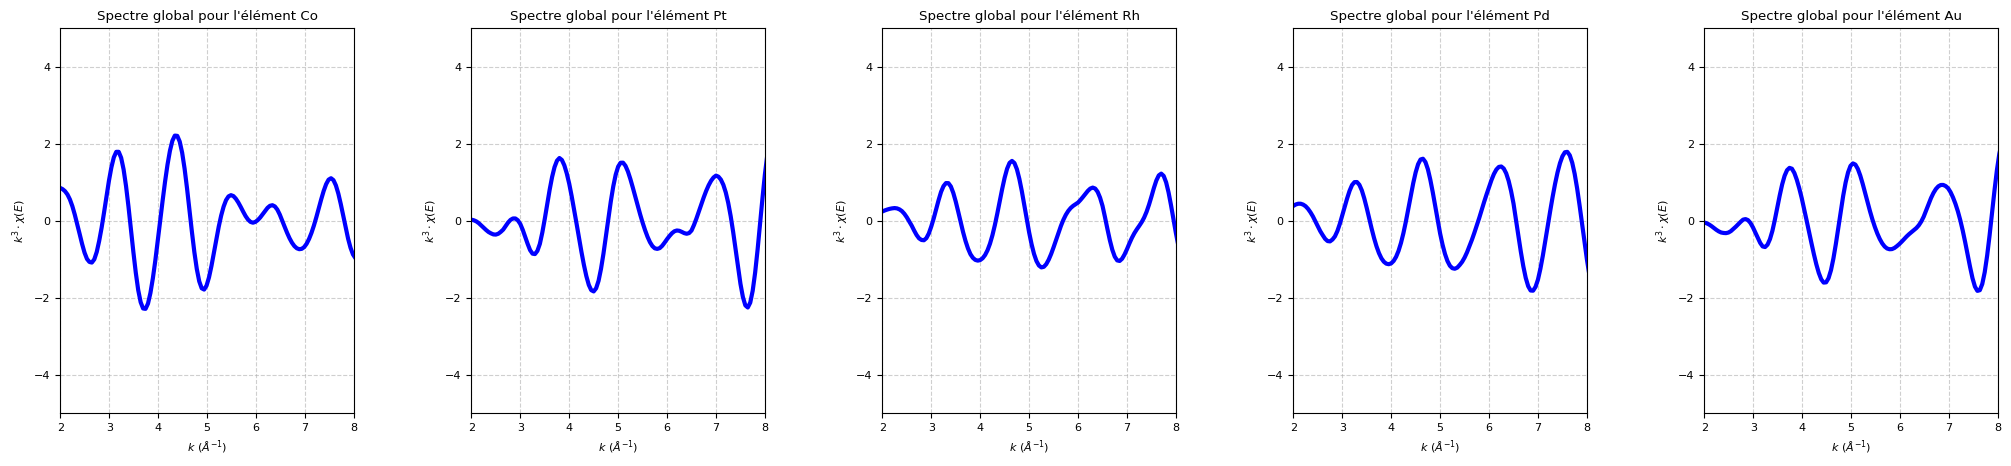

In [11]:
# 1. On calcule la largeur idéale de l'image (par exemple 5 pouces par graphique)
largeur = 5 * len(NP.list_elt)
# 2. L'astuce : on donne [list_elt] à subplot_mosaic !
# Si list_elt = ['Fe', 'Ni'], cela crée la grille [['Fe', 'Ni']]
fig, ax = plt.subplot_mosaic([NP.list_elt], figsize=(largeur, 5))
color={}
color['Co']=(236/255,141/255,157/255)
color['Au']=(238/255,195/255,32/255)
color['Pt']=(178/255,178/255,193/255)
color['Rh']=(178/255,178/255,193/255)
color['Pd']=(178/255,178/255,193/255)

idx=3

if idx==0:
    by=0.15
    ylbl=r"$\chi(E)$"
    savename="chi(k)"
    header="# k (A^-1)   chi(k)"
elif idx==1:
    by=0.30
    ylbl=r"$k\cdot\chi(E)$"
    savename="kchi(k)"
    header="# k (A^-1)   k.chi(k)"
elif idx==2:
    by=1.0
    ylbl=r"$k^2\cdot\chi(E)$"
    savename="k2chi(k)"
    header="# k (A^-1)   k^2.chi(k)"
elif idx==3:
    by=5.0
    ylbl=r"$k^3\cdot\chi(E)$"
    savename="k3chi(k)"
    header="# k (A^-1)   k^3.chi(k)"

save_dir=config['run_dir']/config['simul_dir']/str(config['NP']['seed'])/config['train']['EXAFS_dir']
for elt in NP.list_elt:
    #for i, (k, chi) in enumerate(series[elt][:-1]):
        # L'utilisation de 'enumerate' donne un compteur 'i' (0, 1, 2...) très pratique pour la légende
    #    ax[elt].plot(k, chi*k**idx, label=f"Configuration {i+1}",color=color[elt])
    k,chiglob=series[elt][-1]
    ax[elt].plot(k,chiglob*k**idx, label=f"{elt}",color='blue',linewidth=3)

    # Esthétique du graphique
    ax[elt].set_xlabel(r"$k \ (\AA^{-1})$")
    ax[elt].set_ylabel(ylbl) # Le 'r' permet de lire correctement les caractères spéciaux
    ax[elt].set_title(f"Spectre global pour l'élément {elt}")
    #plt.legend()
    ax[elt].grid(True, linestyle='--', alpha=0.6)
    ax[elt].set_xlim(2, 8)
    ax[elt].set_ylim(-by,by)

    numpy.savetxt(
        save_dir/f"{savename}_{elt}.dat",          # Nom du fichier à créer
        numpy.column_stack((k, chiglob)),           # Les données en colonnes
        delimiter="   ",            # Séparateur (ici 3 espaces, ou '\t' pour une tabulation)
        header=header, # (Optionnel) Première ligne de texte
        comments="# ",              # (Optionnel) Symbole au début de l'entête (comme vos fichiers FEFF)
        fmt="%.6f"                  # (Optionnel) Format des nombres : ici des floats avec 6 décimales
    )
fig.subplots_adjust(wspace=0.4)
plt.savefig(
    f"{savename}.png",  # Nom du fichier (avec l'extension voulue)
    dpi=300,                 # Résolution (300 DPI = qualité impression/publication)
    bbox_inches='tight'      # Ajuste la boîte pour ne JAMAIS couper les labels ou les titres
)

plt.show()